# Geometrically Nonlinear Truss
- Author: Gustavo A. Araújo R.
- Date: March 3, 2026

## A. Setup for Google Colab

**If you're using Google Colab:**
Run the first code cell below (labeled "Colab Setup"). This will prepare your environment by downloading necessary files and installing software, allowing you to run the rest of the notebook.

**If you're running this notebook on your own computer (locally):**
If you have already set up the project (e.g., by running `pip install`), you can skip the "Colab Setup" cell. Otherwise, you can run it, and it will ensure everything is correctly installed.

In [1]:
# --- Colab Setup (run once) ---
import os
import sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/gaaraujo/corotTruss-example.git"
REPO_DIR = "corotTruss-example"  # folder name after clone

IN_COLAB = "COLAB_GPU" in os.environ or "google.colab" in sys.modules
if IN_COLAB:
    # Work in /content when running on Colab
    os.chdir("/content")
    if not Path(REPO_DIR).exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL])
    os.chdir(REPO_DIR)

# Install deps if a requirements file is present
if Path("requirements.txt").exists():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])

# Install package in editable mode if setup.py or pyproject.toml is present
if Path("pyproject.toml").exists() or Path("setup.py").exists():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", "."])

# Fallback: ensure src/ can be imported even without packaging
src_path = str(Path.cwd() / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("✅ Colab setup complete. CWD =", os.getcwd())

✅ Colab setup complete. CWD = /content/corotTruss-example


## B. Some Basic Libraries
We will use numpy and pyplot for data postprocessing and visualization.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "lines.linewidth": 2.5,

    # Frame around plot
    "axes.edgecolor": "#4a4a4a",
    "axes.linewidth": 1.2,

    # Grid (very dim)
    "axes.grid": True,
    "grid.color": "#b0b0b0",
    "grid.alpha": 0.2,
    "grid.linewidth": 0.8,

    # Show full frame
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": True,
    "axes.spines.bottom": True,

    # Tick colors
    "xtick.color": "#4a4a4a",
    "ytick.color": "#4a4a4a",
})

## C. Inclined 2D corotTruss element model

We will build and analyze a simple **inclined 2D truss** in OpenSeesPy step by step. The problem is shown below:

![Inclined truss: initial (grey) and deformed (black) configuration. Node 1 pinned, Node 2 roller; load P and displacement U at node 2.](https://raw.githubusercontent.com/gaaraujo/corotTruss-example/main/inclined_truss.png)

- **Node 1** (lower-left) is at $(0, 0)$ with a **pinned support** (fixed in x and y).
- **Node 2** (upper-right) is at $(\Delta X, \Delta Y)$ with a **roller** that allows vertical motion only (fixed in x, free in y).
- A single **truss element** connects the two nodes. We use a **corotTruss** element so that large displacements and geometric nonlinearity are captured.
- A vertical load $P$ is applied at node 2; we are interested in the $P$–$U$ response, where $U$ is the vertical displacement at node 2.

We will build the model command by command, then run analyses. To compare different ways of driving the solution, we will consider three approaches (we start with the first one in this notebook):

1. **Load control** with a reference load $P_{\mathrm{ref}}$: the load is incremented each step.
2. **Load control** with a reference support displacement: a prescribed displacement at node 2 is incremented each step.
3. **Displacement control**: we impose the displacement at a node and let OpenSees find the load factor on a reference load.

All modeling is done with the OpenSees **basic builder**.

We will assume the truss is made of a material with a stress-strain curve in both tension and compression that follows the model below:
![Stress-strain curve for the material](https://raw.githubusercontent.com/gaaraujo/corotTruss-example/main/material_model.png)

### Problem parameters (feel free to change)

Use this cell to define all geometric, material, and analysis parameters.  
You can change these values and re-run the notebook to explore different cases.

In [3]:
# Geometry
DeltaX = 8.0   # horizontal projection of the element
DeltaY = 1.0   # vertical projection of the element

# Material properties
E = 25000.0   # Young's modulus
F_y = 30.0     # Yield strength
eps_y = F_y / E # Yield strain

# Points in the material model backbone:
material_model = {
    # point: [strain,    stress]
    "A":     [0.0,           0.0],
    "B":     [eps_y,         F_y],
    "C":     [5.0 * eps_y,   1.1 * F_y],
    "D":     [8.0 * eps_y,   0.2 * F_y],
}

# Section properties
A = 1.0       # Cross-sectional area

### Building the model step by step

We use the OpenSees **basic builder** to define the model. The [`model`](https://openseespydoc.readthedocs.io/en/latest/src/model.html) command sets the **spatial dimension** (`ndm`) and **DOFs per node** (`ndf`). For a 2D truss we use `ndm = 2` and `ndf = 2` (x and y translation only; for 2D frames you would use `ndf = 3` to include rotation).

Run the next cell to clear any previous model and create a new one.

In [4]:
# Import opensees
import openseespy.opensees as ops

# Clear any existing model and create a new one: 2D, 2 DOFs per node (truss)
ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 2)

#### Nodes

In OpenSees, every component in the domain (nodes, elements, materials, etc.) is identified by an integer **tag**. We create two nodes with tags 1 and 2 using the [`node`](https://openseespydoc.readthedocs.io/en/latest/src/model.html) command. Node 1 is at the origin $(0, 0)$; node 2 is at $(\Delta X, \Delta Y)$, i.e. the horizontal and vertical projections we defined in the parameters.

In [5]:
ops.node(1, 0.0, 0.0)
ops.node(2, DeltaX, DeltaY)

#### Boundary conditions

We use the [`fix`](https://openseespydoc.readthedocs.io/en/latest/src/fix.htm) command to constrain nodal DOFs. For each DOF we pass **1** (fixed) or **0** (free). With ndf = 2, the DOFs are: 1 = x-translation, 2 = y-translation. So:
- **Node 1**: `fix(1, 1, 1)` — both directions fixed (pinned support).
- **Node 2**: `fix(2, 1, 0)` — x fixed, y free (roller that allows vertical motion).

In [6]:
ops.fix(1, 1, 1)   # Node 1: pinned (fixed x and y)
ops.fix(2, 1, 0)   # Node 2: roller (fixed x, free y)

#### Material

The truss element uses a **uniaxial** material (stress–strain along the bar). OpenSees provides a wide catalog of uniaxial materials. In the cell below you will see a few defined for you to explore:

- [`Elastic`](https://openseespydoc.readthedocs.io/en/latest/src/ElasticUni.html): As its names suggests, only accounts for elastic behavior (A-B portion of the material backbone.
- [`Steel01`](https://openseespydoc.readthedocs.io/en/latest/src/steel01.html): This is a bilinear model. It is equivalent to modeling the A-B-C portion of the material backbone.
- [`Hysteretic`](https://openseespydoc.readthedocs.io/en/latest/src/Hysteretic.html): This is a trilinear model, which allows for modeling the entire A-B-C-D material backbone.

In [7]:
# Backbone points (strain, stress)
epsB, sigB = material_model["B"]
epsC, sigC = material_model["C"]
epsD, sigD = material_model["D"]

# Elastic stiffness and hardening ratio
E = sigB / epsB
b = (sigC - sigB) / (E * (epsC - epsB))

# --------------------------------- Material 1 ---------------------------------
# Elastic material
ops.uniaxialMaterial("Elastic", 1, E)

# --------------------------------- Material 2 ---------------------------------
# Bilinear steel material
ops.uniaxialMaterial("Steel01", 2, sigB, E, b)

# --------------------------------- Material 3 ---------------------------------
# Hysteretic backbone (stress, strain pairs)
pos = (sigB, epsB, sigC, epsC, sigD, epsD)
neg = (-sigB, -epsB, -sigC, -epsC, -sigD, -epsD)

# Pinching and damage parameters
pinch = (0.8, 0.8)
damage = (0.0, 0.0, 0.0)

ops.uniaxialMaterial("Hysteretic", 3, *pos, *neg, *pinch, *damage)


You can use the section below to explore what the hysteretic behavior fo the three materials looks like

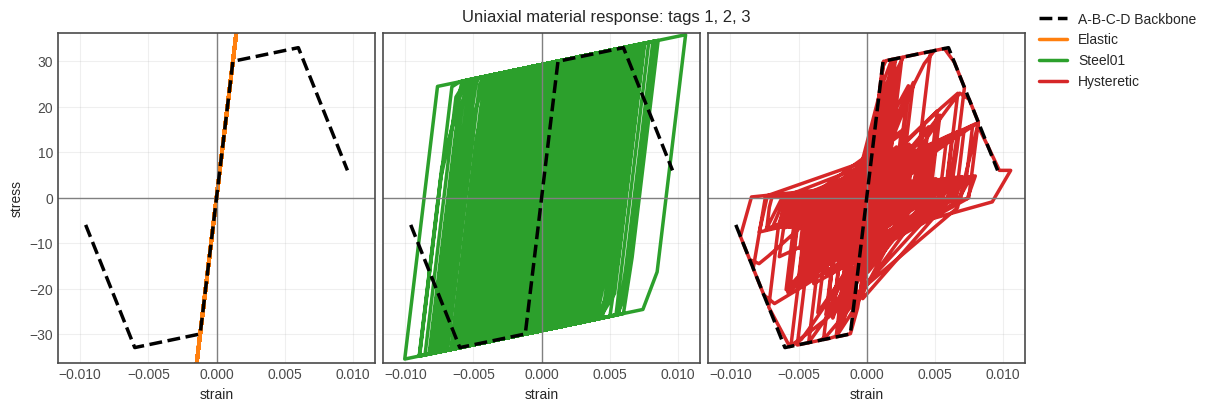

In [8]:
from opensees_material_testing import test_uniaxialMaterial

# Material backbone
backbone = []
for point in material_model:
    strain, stress = material_model[point]
    backbone.append([strain, stress])
    if strain != 0.0 or stress != 0.0:
        backbone.append([-strain, -stress])
backbone = np.array(backbone)
backbone = backbone[backbone[:, 0].argsort()]

# Plot materials
material_tags = [1, 2, 3]
colors = plt.get_cmap("tab10").colors
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, layout='constrained')
for mat_tag, ax in zip(material_tags, axes):
    eps, sig = test_uniaxialMaterial(material_tag=mat_tag, max_strain=1.1 * np.max(backbone[:,0]))
    if mat_tag == 1:
      ax.plot(backbone[:, 0], backbone[:, 1], linestyle='--', color='black', label='A-B-C-D Backbone', zorder=10)
    else:
      ax.plot(backbone[:, 0], backbone[:, 1], linestyle='--', color='black', zorder=10)
    mat_label = "Elastic" if mat_tag == 1 else "Steel01" if mat_tag == 2 else "Hysteretic"
    ax.plot(eps, sig, label=mat_label, color=colors[mat_tag])
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=1)
    ax.set_xlabel("strain")
    ax.grid(True)

axes[0].set_ylabel("stress")
axes[0].set_ylim(-max(backbone[:, 1]) * 1.1, max(backbone[:, 1]) * 1.1)
fig.suptitle("Uniaxial material response: tags 1, 2, 3")
fig.legend(loc='outside right upper')
plt.show()

#### Element: corotTruss

We use a [**corotational truss**](https://openseespydoc.readthedocs.io/en/latest/src/corotTruss.html) element so that the formulation accounts for large displacements and rotations (geometric nonlinearity). The element is given a tag (e.g. 1), the two node tags, the cross-sectional area $A$, and the material tag.

In [9]:
# corotTruss: element tag 1, nodes 1 and 2, area A, material tag 1
material_tag = 1 # can be any of the three materials defined above
ops.element('corotTruss', 1, 1, 2, A, material_tag)

#### Visualizing the model

We can draw the model using [**opsvis**](https://opsvis.readthedocs.io/en/stable/index.html), a postprocessing and visualization library for OpenSeesPy. It is developed by [Seweryn Kokot](https://github.com/sewkokot) and is separate from OpenSees; such tools are easy to build with some Python scripting.

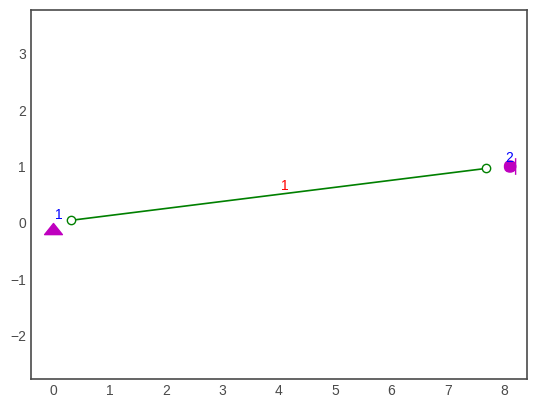

In [10]:
import opsvis
opsvis.plot_model()
plt.show()

#### Wrapping the model in a function

To run different analysis cases (load control, displacement control, etc.) we will need to rebuild the same model each time. So we put all the modeling commands above into a single **build_model()** function. Run the next cell to define it; you can call `build_model()` whenever you need a fresh copy of the structure.

> **MATERIAL MODEL**: You will notice I added an optional parameter, `material_tag`, to choose between the three material models we defined previously. If you want to play around with the code, change `DEFAULT_MATERIAL_TAG` to 1, 2, or 3, and see what happens!

In [11]:
DEFAULT_MATERIAL_TAG = 1 # can be 1, 2, or 3
def build_model(material_tag = DEFAULT_MATERIAL_TAG):
    """Build the inclined 2D truss: pin at node 1, roller at node 2, corotTruss element."""
    # Model
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 2)
    # Nodes
    ops.node(1, 0.0, 0.0)
    ops.node(2, DeltaX, DeltaY)
    # Boundary conditions
    ops.fix(1, 1, 1)
    ops.fix(2, 1, 0)
    # Material
    eps_B, sig_B = material_model["B"]
    eps_C, sig_C = material_model["C"]
    eps_D, sig_D = material_model["D"]
    E = sig_B / eps_B
    if material_tag == 1:
        ops.uniaxialMaterial('Elastic', material_tag, E)
    elif material_tag == 2:
        b = (sig_C - sig_B) / (E * (eps_C - eps_B))
        ops.uniaxialMaterial('Steel01', material_tag, sig_B, E, b)
    else:
        ops.uniaxialMaterial('Hysteretic', material_tag,
                      sig_B, eps_B, sig_C, eps_C, sig_D, eps_D,
                      -sig_B, -eps_B, -sig_C, -eps_C, -sig_D, -eps_D,
                      0.8, 0.8, 0.0, 0.0, 0.0)
    # Element
    ops.element('corotTruss', 1, 1, 2, A, material_tag)

## D. Goal: P vs U

We want to obtain the relationship between the **vertical load** $P$ applied at node 2 and the **vertical displacement** $U$ at that node (P–U curve). There are three common ways to do this:

1. **Load control with a reference load**  
   Apply a reference load $P_{\mathrm{ref}}$ and use **LoadControl** to increment the load factor in each step. The applied load is $P = \lambda \cdot P_{\mathrm{ref}}$.

2. **Load control with a reference support displacement**  
   Use a single-point constraint (e.g. `sp`) to prescribe a reference displacement at node 2, and use **LoadControl** to increment the factor that scales that displacement. This is the recommended approach if you want to enforce a spatial displacement distribution.

3. **Displacement control**  
   Apply a reference load in a load pattern and use **DisplacementControl** to increment the vertical displacement at node 2. The solver finds the load factor $\lambda$ so that $P = \lambda \cdot P_{\mathrm{ref}}$. This is the recommended approach if you want to enforce a spatial force distribution while controlling a single DOF; e.g., for a pushover analysis.


### Recording Response

OpenSeesPy offers several ways to record analysis results. The simplest method is to capture specific responses after each successful analysis step. We'll create a helper function to record key results into a dictionary.

In [12]:
# Helper functions to record results during the analysis loop

def init_history():
    """Initialize a dictionary to store analysis results."""
    return {
        'step': [0],
        'lambda':  [0.0],   # load factor
        'U':   [0.0],   # vertical displacement at node 2
        'q':    [0.0],   # axial force in the truss element
        'v':    [0.0],   # axial deformation in the truss element
        'R1':  [[0.0, 0.0]],   # reactions at node 1
        'R2':  [[0.0, 0.0]],   # reactions at node 2
    }


def record_step(history, step, pattern_tag=1):
    """Record one analysis step: load factor, displacement at node 2, element force/deformation, and reactions."""
    lam = ops.getLoadFactor(pattern_tag)
    U  = ops.nodeDisp(2, 2)

    # Element axial force (local end force at node 1)
    q = ops.basicForce(1)[0]
    v = ops.basicDeformation(1)[0]

    # Compute reactions (must be called before nodeReaction)
    ops.reactions()
    R1 = ops.nodeReaction(1)
    R2 = ops.nodeReaction(2)

    history['step'].append(step)
    history['lambda'].append(lam)
    history['U'].append(U)
    history['q'].append(q)
    history['v'].append(v)
    history['R1'].append(R1)
    history['R2'].append(R2)

### Case 1 – Load control with a reference load

We apply a **reference load** $P_{\mathrm{ref}}$ at node 2 and use **LoadControl** to increase the load factor $\lambda$ each step, so $P(t) = P_{ref}\, \lambda(t)$ with $\lambda(t)=t$ (load increases with the time step).

We will see that load control often cannot trace the full force–displacement curve once the resisting load starts to drop (e.g. in the inelastic range).

> **Solver note.** OpenSees’ default equation solver is **ProfileSPD**, which assumes the tangent stiffness matrix is **symmetric positive definite**. For problems where softening occurs or there is geometric nonlinearity, the effective stiffness can become negative and that assumption fails. For this kind of analysis we therefore switch to a solver that does not require positive definiteness: the banded solver **BandGeneral** (usually enough for small problems), or the sparse solvers **UmfPack** and **SuperLU**. The remaining analysis options (numberer, constraints, convergence test, algorithm) are standard starting points you can reuse in most static analyses.

In [13]:
# Case 1: LoadControl + nodal load

# Build model
build_model()

# Time series, lambda(t) = t
ops.timeSeries('Linear', 10); # Linear time series with tag = 10

# Define applied load, P(t) = Pref * lambda(t)
ops.pattern('Plain', 1, 10)  # Load pattern with tag = 1 tied to a time series with tag = 10
Pref = -1.0
ops.load(2, 0.0, Pref) # load node 2 with -Pref in the y direction (dof = 2)

# Analysis options (see solver note above: BandGeneral for small problems; UmfPack/SuperLU also work)
ops.system('BandGeneral')
ops.numberer('RCM')       # how equations are numbered
ops.constraints('Plain')  # how constraints (boundary conditions) are handled
ops.test('NormUnbalance', 1.0e-6, 25) # how convergence is tested
ops.algorithm('KrylovNewton')   # how the nonlinear equations are solved

# Target applied load at the end of the analysis.
# The actual load at node 2 will be
# P = lambda * Pref, so we choose lambda_final = |Ptarget/Pref|.
Ptarget = -20.0 # target load at the end of the analysis
nSteps = 50 # number of steps in the analysis
lambda_final = abs(Ptarget / Pref)
dLambda = lambda_final / nSteps # lamdba increment in each step
ops.integrator('LoadControl', dLambda) # how lambda is increased
ops.analysis('Static')

# Initialize variables to store analysis results (empty lists)
data = init_history()

# Run analysis
print(f"Running Case 1: LoadControl + load with {nSteps} steps...")

# We do the analysis in a loop so that we can record things at each step
for step in range(1, nSteps + 1):
    ok = ops.analyze(1) # analyze one step

    # check if analysis converged
    if ok != 0:
        print(f"  Analysis failed at step {step}")
        break # stop analysis

    # if analysis converged, record forces and displacements
    record_step(data, step, pattern_tag=1)

print("Done. Last step:")
if data['step']:
    print(f"  step   = {data['step'][-1]}")
    print(f"  lambda = {data['lambda'][-1]:.3f}")
    print(f"  U      = {data['U'][-1]:.3f}")
    print(f"  R1     = {data['R1'][-1]}")
    print(f"  R2     = {data['R1'][-1]}")
    print(f"  q      = {data['q'][-1]:.3f}")
    print(f"  v      = {data['v'][-1]:.3f}")
else:
    print("  (no successful steps)")

Running Case 1: LoadControl + load with 50 steps...
  Analysis failed at step 24
Done. Last step:
  step   = 23
  lambda = 9.200
  U      = -0.389
  R1     = [120.46817393239351, 9.199999179224779]
  R2     = [120.46817393239351, 9.199999179224779]
  q      = -120.819
  v      = -0.039


after: 25 iterations  current Norm: 1.16631 (max: 1e-06, Norm deltaX: 0.24502)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 9.6
OpenSees > analyze failed, returned: -3 error flag


Notice how the analysis does not complete all the prescribed steps and fails to converge (i.e., find equilibrium) roughly close to half the specified load. To diagnose what's happening, let's plot the recorded response up to the failure point.

We define a function to plot response that we can reuse for future analyses.

In [14]:
def plot_response(*, P=None, U=None, q=None, v=None, suptitle=None):
  """ Generate plots of applied load P, displacement U, axial force q, and deformation v"""

  fig, axes = plt.subplots(2, 2, figsize=(10, 8), layout='constrained')

  if P is not None and U is not None:
    axes[0, 0].plot(-U, -P, 'o-')
    axes[0, 0].axhline(y=0, color='gray', linestyle='-', linewidth=1)
    axes[0, 0].axvline(x=0, color='gray', linestyle='-', linewidth=1)
    axes[0, 0].set_xlabel('Vertical displacement at node 2, $u_{2,y}$')
    axes[0, 0].set_ylabel('Applied load at node 2, $P$')
    axes[0, 0].grid(True)

  if U is not None and q is not None:
    axes[0, 1].plot(-U, -q, 'o-')
    axes[0, 1].axhline(y=0, color='gray', linestyle='-', linewidth=1)
    axes[0, 1].axvline(x=0, color='gray', linestyle='-', linewidth=1)
    axes[0, 1].set_xlabel('Vertical displacement at node 2, $u_{2,y}$')
    axes[0, 1].set_ylabel('Axial force, $q$')
    axes[0, 1].grid(True)

  if U is not None and v is not None:
    axes[1, 0].plot(-U, -v, 'o-')
    axes[1, 0].axhline(y=0, color='gray', linestyle='-', linewidth=1)
    axes[1, 0].axvline(x=0, color='gray', linestyle='-', linewidth=1)
    axes[1, 0].set_xlabel('Vertical displacement at node 2, $u_{2,y}$')
    axes[1, 0].set_ylabel('Axial deformation, $v$')
    axes[1, 0].grid(True)

  if v is not None and q is not None:
    axes[1, 1].plot(-v, -q, 'o-')
    axes[1, 1].axhline(y=0, color='gray', linestyle='-', linewidth=1)
    axes[1, 1].axvline(x=0, color='gray', linestyle='-', linewidth=1)
    axes[1, 1].set_xlabel('Axial deformation, $v$')
    axes[1, 1].set_ylabel('Axial force, $q$')
    axes[1, 1].grid(True)

  if suptitle:
    fig.suptitle(suptitle, fontsize=12)
  plt.show()


  return fig, axes

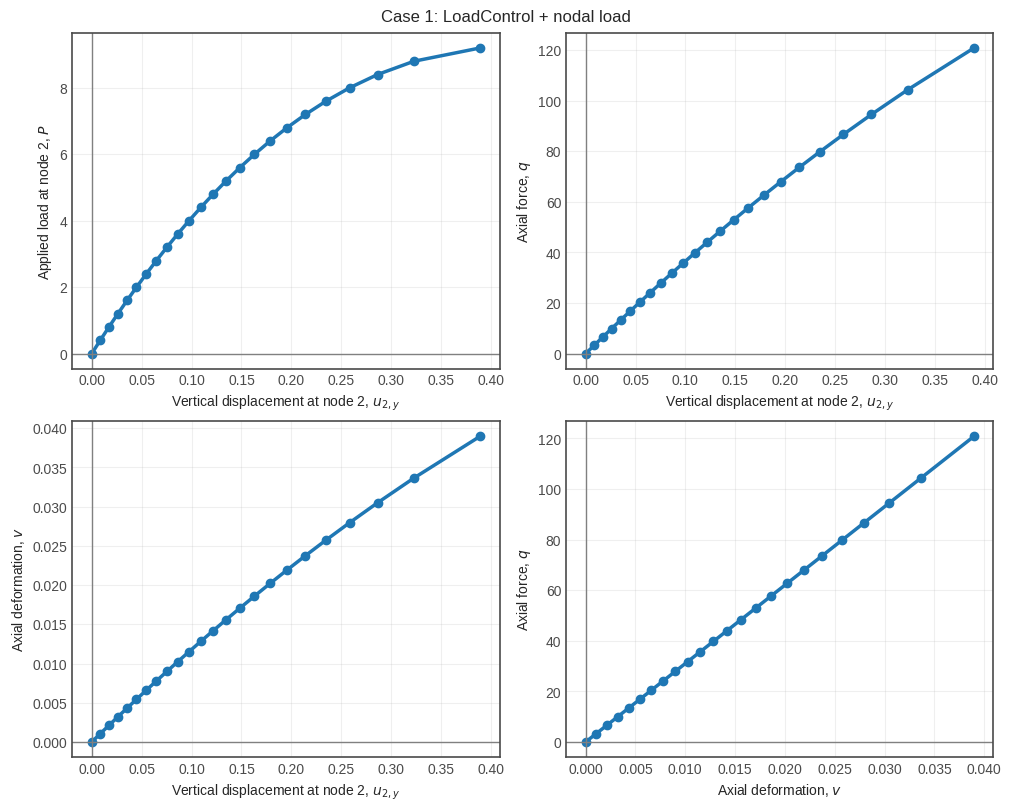

In [15]:
# Plot for Case 1: load vs displacement at node 2

if data['step']:
    P = np.array(data['lambda']) * Pref
    U = np.array(data['U'])
    R1y = np.array(data['R1'])[:,1]
    q  = np.array(data['q'])
    v = np.array(data['v'])

    plot_response(P=P, U=U, q=q, v=v, suptitle='Case 1: LoadControl + nodal load')
else:
    print("No data stored for Case 1.")

Notice that the analysis stops right when the $P$–$u_{2,y}$ curve starts to flatten and approach a peak. This is a very common limitation of the **LoadControl** integrator: it can follow the response while the load is increasing, but it cannot step past a peak in the load–displacement curve. Beyond the peak, trying to increase the applied load would require the structure to develop a resisting force larger than its peak strength, so the solver cannot find equilibrium and the iterations fail to converge.

For this simple example, which has only one free DOF, we can make LoadControl work by changing the "driver" of the problem: instead of increasing a nodal load, we will increment a prescribed support displacement. That is exactly what we will do in the next case.

### Case 2 – Load control with `sp` at the roller node

In **Case 2** we keep the same inclined truss model, but instead of applying a nodal load at node 2 we prescribe a **support displacement** at the roller node using the `sp` command.  
We choose a reference support displacement `Uref = -1.0` at node 2, degree of freedom 2 (vertical). The load factor $\lambda$ from `LoadControl` then scales this reference value so that the imposed displacement history is

$$ u_{2,y}(t) = \lambda(t) \, U_{\mathrm{ref}}. $$

Because we are driving the model through a prescribed support displacement, the external load $P$ is no longer given by a reference nodal load; instead we recover it **from the vertical reaction at node 2**

$$ P = R_{2y}, $$

> **Constraint handler note.** When we introduce an `sp` constraint, the simple `Plain` constraint handler generally **will not work**, because we now have to eliminate prescribed DOFs consistently from the global system. For this case we will use the `Transformation` constraint handler, which performs the required **static condensation** of the constrained DOFs. The `Transformation` handler is powerful but can be tricky to use correctly; if you are unsure about your results, it is often safer to switch to the `Auto` constraint handler, which tries to select an appropriate constraint strategy for the current model automatically.

> **System solver note.** In this type of example, all DOFs are effectively constrained once we impose the support motion, so there are **no equilibrium equations to solve**. Most of the standard equation solvers in OpenSees will crash or cause kernel issues in this situation. For Case 2 we therefore use `ops.system('UmfPack')`, which is one of the few solvers that can handle models with zero equations cleanly. For more background on this issue, see Michael Scott's blog post ["Most Solvers Can Be Marplots"](https://portwooddigital.com/2020/08/27/most-solvers-can-be-marplots/).

In [16]:
# Case 2: LoadControl + prescribed support displacement (sp) at the roller node

# Build model (start from the same geometry and material definition)
build_model()

print("Model built")
# Time series: lambda(t) = t
ops.timeSeries('Linear', 20)

# Load pattern with a prescribed support displacement at node 2, dof 2
ops.pattern('Plain', 2, 20)
Uref = -1.0  # reference vertical support displacement at node 2
ops.sp(2, 2, Uref)
print("Constraint defined")

# Analysis options
ops.system('UmfPack')
ops.numberer('RCM')
# With an sp constraint we cannot use the Plain constraint handler here.
# The Transformation handler performs the static condensation needed
# to enforce the prescribed support motion consistently.
ops.constraints('Transformation')
ops.test('NormUnbalance', 1.0e-6, 25)
ops.algorithm('KrylovNewton')

# Target support displacement at the end of the analysis (in the same
# sign convention as Uref). The actual displacement at node 2 will be
# u_2y = lambda * Uref, so we choose lambda_final = |Utarget/Uref|.
Utarget = -2.5
nSteps = 50
lambda_final = abs(Utarget / Uref)
dLambda = lambda_final / nSteps
ops.integrator('LoadControl', dLambda)
ops.analysis('Static')

# Initialize history container and run the analysis
case2_data = init_history()

print(f"Running Case 2: LoadControl + sp with {nSteps} steps...")
for step in range(1, nSteps + 1):
    ok = ops.analyze(1)
    if ok != 0:
        print(f"  Analysis failed at step {step}")
        break

    # pattern_tag=2 so we retrieve the load factor associated with this pattern
    record_step(case2_data, step, pattern_tag=2)

print("Done. Last step:")
if case2_data['step']:
    print(f"  step   = {case2_data['step'][-1]}")
    print(f"  lambda = {case2_data['lambda'][-1]:.3f}")
    print(f"  U      = {case2_data['U'][-1]:.3f}")
    print(f"  R1     = {case2_data['R1'][-1]}")
    print(f"  R2     = {case2_data['R1'][-1]}")
    print(f"  q      = {case2_data['q'][-1]:.3f}")
    print(f"  v      = {case2_data['v'][-1]:.3f}")
else:
    print("  (no successful steps)")

Model built
Constraint defined
Running Case 2: LoadControl + sp with 50 steps...
Done. Last step:
  step   = 50
  lambda = 2.500
  U      = -2.500
  R1     = [-235.1422444836451, 44.08917084068342]
  R2     = [-235.1422444836451, 44.08917084068342]
  q      = 239.240
  v      = 0.077


Notice how in this case we were able to complete all the steps successfully using load control + an `sp` constraint. Let us look at the recorded response.

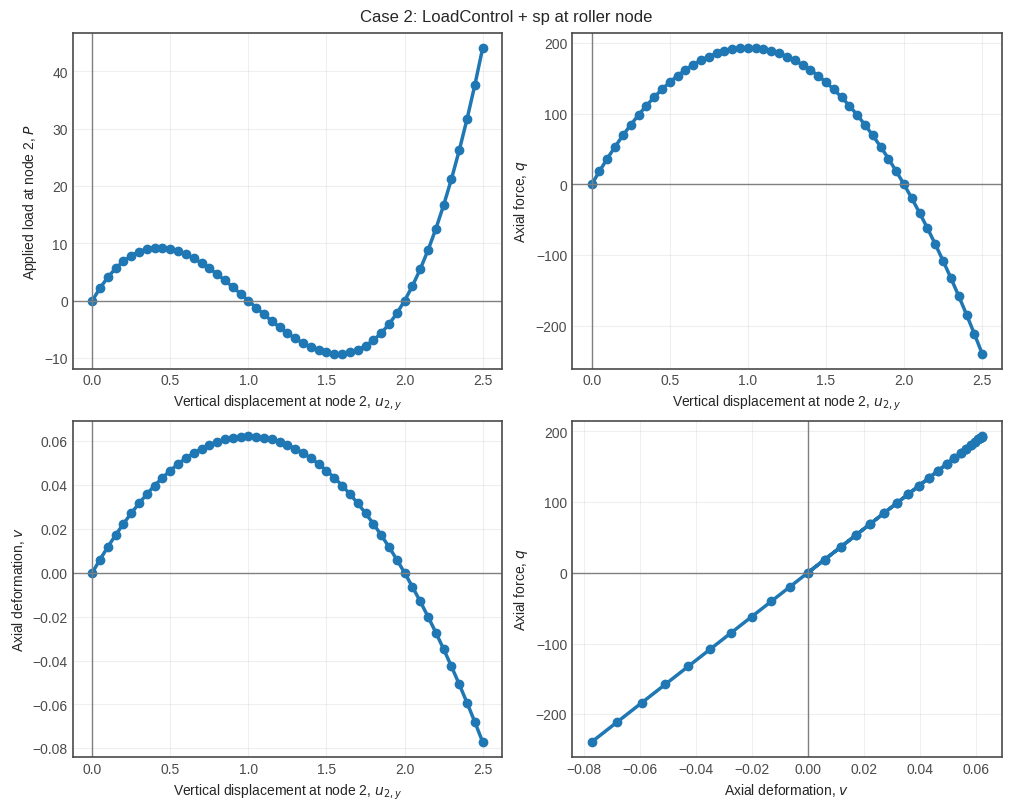

In [17]:
# Plot for Case 2: reaction-based P vs displacement at node 2

if case2_data['step']:
    U2 = np.array(case2_data['U'])           # vertical displacement at node 2
    R2 = np.array(case2_data['R2'])          # reactions at node 2
    R2y = R2[:, 1]

    # In this case we define the external load from the reaction at node 2
    P2 = R2y

    q2 = np.array(case2_data['q'])           # axial force in the truss
    v2 = np.array(case2_data['v'])           # axial deformation in the truss

    plot_response(P=P2, U=U2, q=q2, v=v2, suptitle='Case 2: LoadControl + sp at roller node')
else:
    print("No data stored for Case 2.")

Notice how the $P$ - $u_{2,y}$ curve is highly nonlinear, even though the element is behaving elastically (check $q$-$v$ plot in the lower right). This indicates that the nonlinearity is primarily coming from the changing geometry of the truss, not material behavior. The type of behavior we are seeing here, where the structure suddenly changes its configuration under increasing load, is known as **snap-through**.

### Case 3 – Displacement control with nodal load

In **Case 3** we use the `DisplacementControl` integrator to drive the analysis. This approach involves applying a reference load ($P_{\mathrm{ref}}$) at node 2 within a load pattern, and then incrementing the vertical displacement ($U$) at that node. The integrator will automatically determine the load factor ($\lambda$) at each step such that the applied load becomes $P = \lambda \cdot P_{\mathrm{ref}}$. This method is particularly useful when you want to control a specific displacement degree of freedom while still dealing with a defined force distribution, such as in pushover analyses. You can control **only one degree of freedom (DOF)** with displacement control.

We will aim to trace the complete P–U curve for the truss, including post-peak behavior, which is often difficult to capture with simple load control methods.

In [18]:
# Case 3: DisplacementControl

# Build model (start from the same geometry and material definition)
build_model()

print("Model built")
# Time series, lambda(t) = t
ops.timeSeries('Linear', 30); # Linear time series with tag = 30

# Define applied load, P(t) = Pref * lambda(t)
ops.pattern('Plain', 3, 30)  # Load pattern with tag = 3 tied to a time series with tag = 30
Pref = -1.0
ops.load(2, 0.0, Pref) # load node 2 with -Pref in the y direction (dof = 2)

# Analysis options
ops.system('BandGeneral')
ops.numberer('RCM')       # how equations are numbered
ops.constraints('Plain')  # how constraints (boundary conditions) are handled
ops.test('NormUnbalance', 1.0e-6, 25) # how convergence is tested
ops.algorithm('KrylovNewton')   # how the nonlinear equations are solved

# Target free displacement at the end of the analysis
Utarget = -2.5
nSteps = 50
dU = Utarget / nSteps # displacement increment
# increase displacement in node 2, dof 2, by an amount dU in every step
ops.integrator('DisplacementControl', 2, 2, dU)
ops.analysis('Static')

# Initialize history container and run the analysis
case3_data = init_history()

print(f"Running Case 3: DisplacementControl with {nSteps} steps...")
for step in range(1, nSteps + 1):
    ok = ops.analyze(1)
    if ok != 0:
        print(f"  Analysis failed at step {step}")
        break

    # pattern_tag=3 so we retrieve the load factor associated with this pattern
    record_step(case3_data, step, pattern_tag=3)

print("Done. Last step:")
if case3_data['step']:
    print(f"  step   = {case3_data['step'][-1]}")
    print(f"  lambda = {case3_data['lambda'][-1]:.3f}")
    print(f"  U      = {case3_data['U'][-1]:.3f}")
    print(f"  R1     = {case3_data['R1'][-1]}")
    print(f"  R2     = {case3_data['R1'][-1]}")
    print(f"  q      = {case3_data['q'][-1]:.3f}")
    print(f"  v      = {case3_data['v'][-1]:.3f}")
else:
    print("  (no successful steps)")

Model built
Running Case 3: DisplacementControl with 50 steps...
Done. Last step:
  step   = 50
  lambda = 44.089
  U      = -2.500
  R1     = [-235.1422444836451, 44.08917084068342]
  R2     = [-235.1422444836451, 44.08917084068342]
  q      = 239.240
  v      = 0.077


Notice how in this case we were able to complete all the steps successfully using displacement control. Let us look at the recorded response.

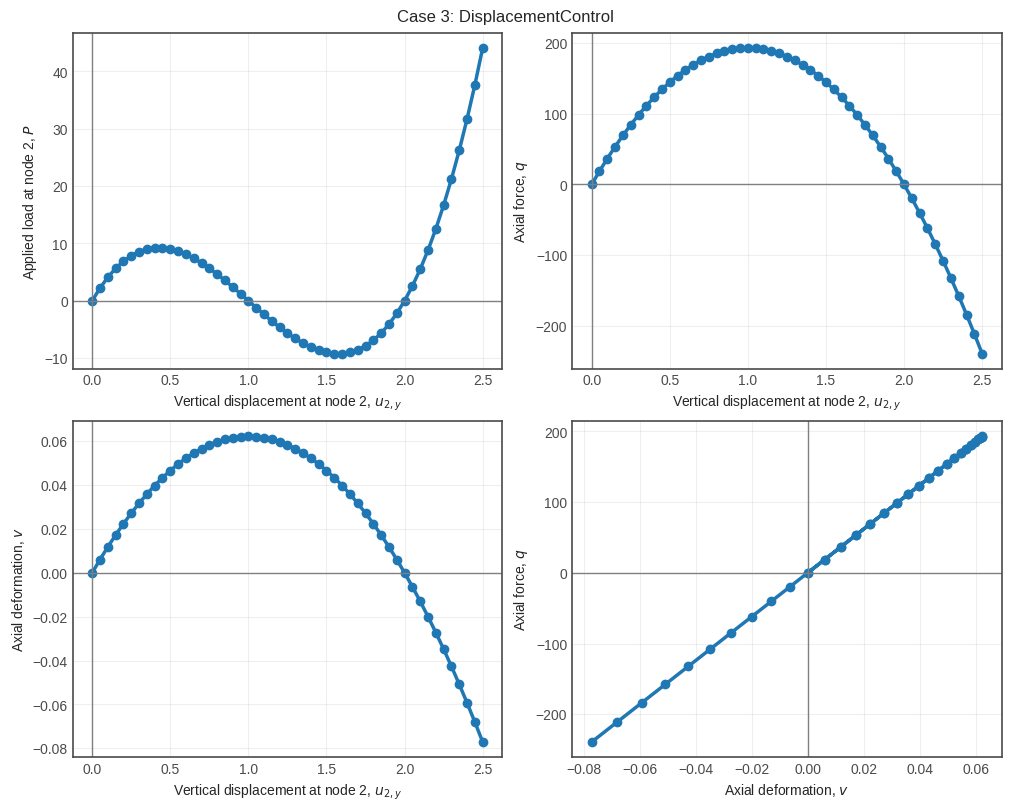

In [19]:
# Plot for Case 3: reaction-based P vs displacement at node 2

if case3_data['step']:
    P3 = np.array(case3_data['lambda']) * Pref
    U3 = np.array(case3_data['U'])
    R1y = np.array(case3_data['R1'])[:,1]
    q3  = np.array(case3_data['q'])
    v3 = np.array(case3_data['v'])

    plot_response(P=P3, U=U3, q=q3, v=v3, suptitle='Case 3: DisplacementControl')
else:
    print("No data stored for Case 3.")

Note that `DisplacementControl` gives us the same relationshiop for $P$-$U$ as `LoadControl` with an `sp` constraint. This is the case because there is only one free DOF. Generally, the resulting $P$-$U$ would differ for multi-DOF systems, given that the first approach imposes a deformed shape while the second one enforces a loading distribution.